# 3 — Latent Diffusion Model (LDM): generazione

Secondo stadio: un **modello di diffusione latente** (`DiffusionModelUNetMaisi`, 178.566.276 parametri) addestrato **incondizionatamente** nel latente del VAE, con scheduler **Rectified Flow** (30 step di inferenza). Da rumore gaussiano l'LDM produce un latente, decodificato dal VAE (v2) in un volume `256^3`.

**Interventi lato LDM:**
- normalizzazione dei latenti **per-canale** e **centrata** (i 4 canali hanno std che variano ~3.6x e una media a -3.5, che uno scale scalare globale non condiziona bene);
- **curriculum a due fasi** sul campionamento dei timestep in training:
    - fase 1 (epoca < 500): **uniform** — consolida la struttura globale (posizione/scala), che si stabilisce ai timestep ad alto rumore;
    - fase 2 (epoca >= 500): **logit-normal** (loc=0, scale=1) — affina la texture (mid-range della traiettoria).
- **autoguidance** al sampling: `v = v_bad + w*(v_good - v_bad)`, w=2.0, con `v_bad` un checkpoint precoce dello stesso run. Sostituisce la CFG (non applicabile a un modello incondizionato).

Il curriculum nasce da un'osservazione della v4: il logit-normal *statico* dava FID migliore ma ~20% di campioni con **traslazione globale** (struttura appresa male ai timestep alti); l'uniform *statico* azzerava le traslazioni ma perdeva nitidezza. Il curriculum ottiene **entrambe** (vedi notebook 4).

Modello finale: **curriculum, checkpoint epoch 800 + autoguidance**. Visualizziamo alcuni dei 100 campioni in `data/synthetic_v5/`.

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s // 2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes=ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Esempi di MRI sintetiche

100 volumi sintetici disponibili


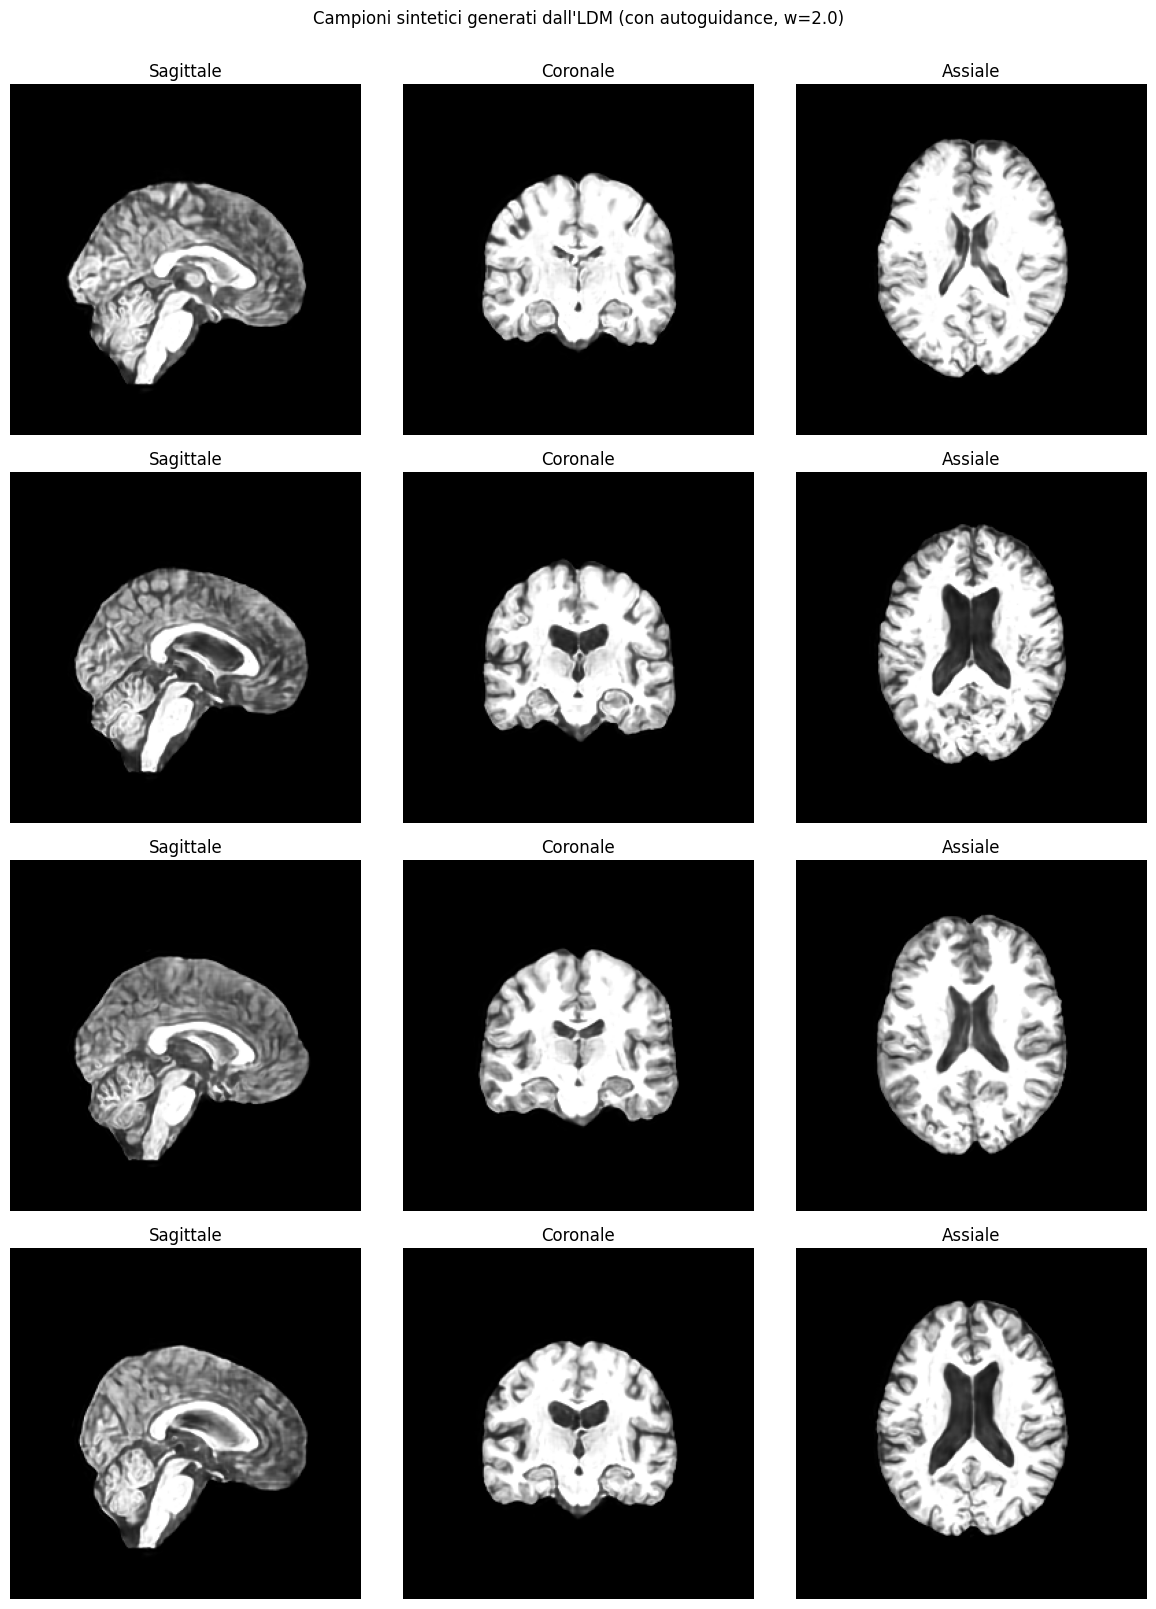

In [2]:
synth_files=sorted(glob.glob("data/synthetic_v5/hc_synth_*.nii.gz"))
print(f"{len(synth_files)} volumi sintetici disponibili")

n_show=4
fig, axes=plt.subplots(n_show, 3, figsize=(12, 4*n_show))
for r in range(n_show):
    vol=nib.load(synth_files[r]).get_fdata()
    show_ortho(vol, ax_row=axes[r])
plt.suptitle("Campioni sintetici generati dall'LDM (con autoguidance, w=2.0)", y=1.003)
plt.tight_layout(); plt.show()

## Diversita' dei campioni
Slice assiale di molti campioni: verifica visiva dell'assenza di *mode collapse*.

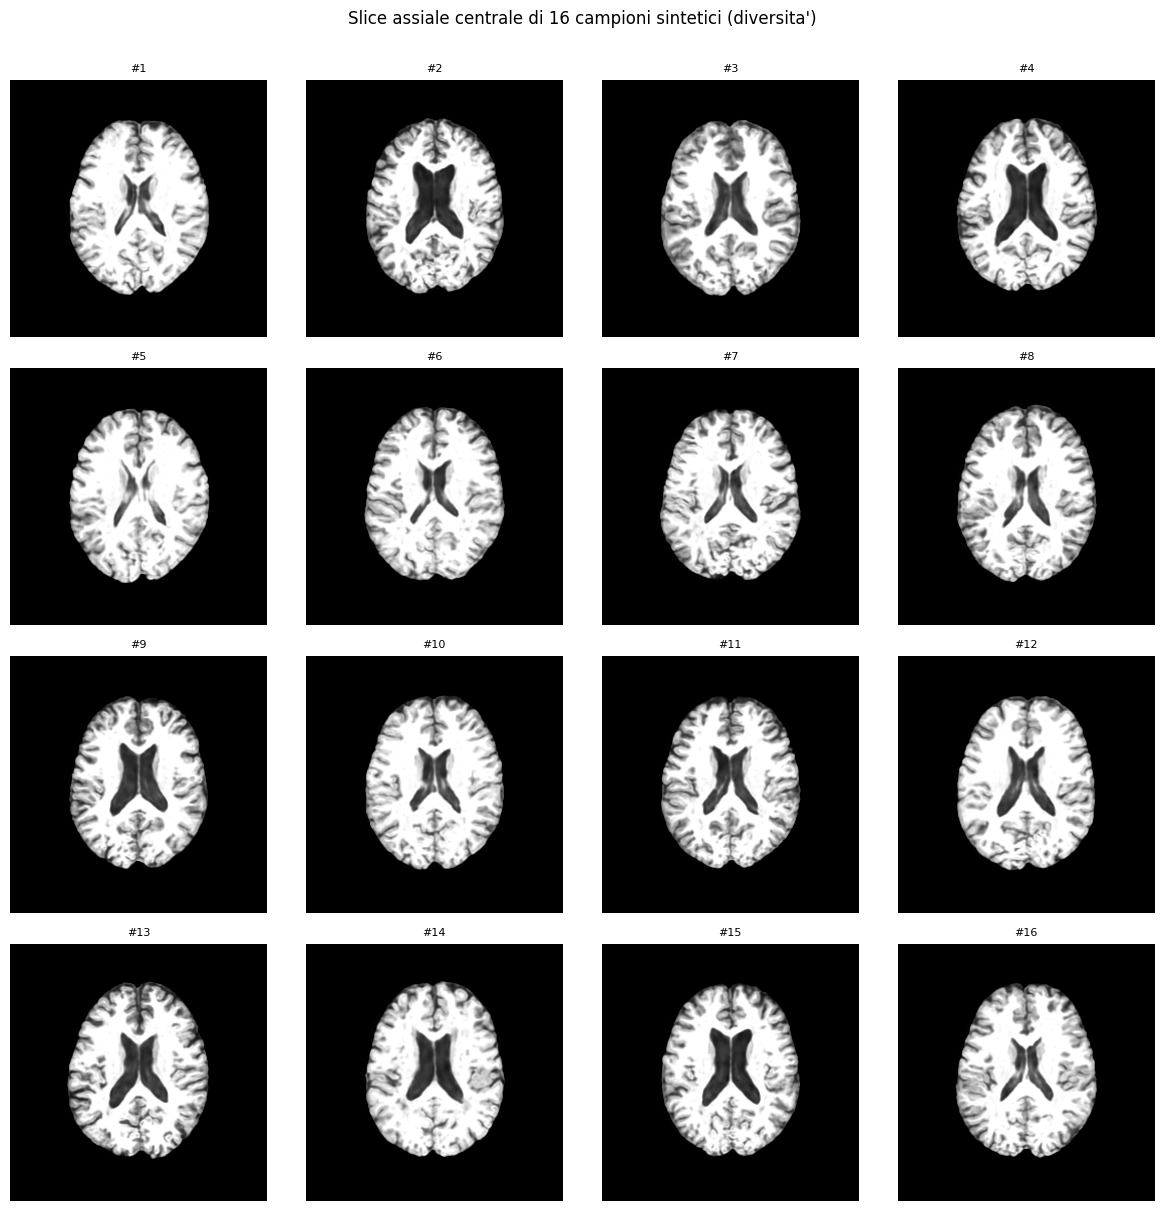

In [3]:
n_grid=min(16, len(synth_files))
cols=4; rows=(n_grid+cols-1)//cols
fig, axes=plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
for i, ax in enumerate(axes.flat):
    if i<n_grid:
        vol=nib.load(synth_files[i]).get_fdata()
        z=vol.shape[2]//2
        ax.imshow(np.rot90(vol[:,:,z]), cmap="gray")
        ax.set_title(f"#{i+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Slice assiale centrale di 16 campioni sintetici (diversita')", y=1.005)
plt.tight_layout(); plt.show()

**Osservazione.** I campioni mostrano anatomia riconoscibile e **variano** tra loro (ventricoli, solchi, proporzioni): nessun mode collapse (conferma quantitativa nel notebook 4 via MS-SSIM, 0.949 vs 0.936 reali).

**Posizionamento corretto.** Tutti i campioni sono centrati, di dimensione piena, non tagliati (0% traslati, verificato con `tests/check_degenerate_samples.py`, sia con sia senza guida). E' il risultato del curriculum: la fase 1 uniform consolida la geometria, che regge anche quando la fase 2 logit-normal ne affina la texture.

**Nitidezza.** Rispetto al modello a soli timestep uniformi, la texture corticale e' piu' definita (coerente con FID 24.3 vs 27.2 dell'uniform): la fase 2 logit-normal recupera parte del dettaglio senza rompere il posizionamento.

Il piano **sagittale** resta il piu' impegnativo, ma il divario coi piani assiale/coronale e' il piu' contenuto fra tutte le configurazioni testate (FID YZ 27.3 vs XY 25.5, notebook 4).